<a href="https://colab.research.google.com/github/aghosh92/Course-Lectures/blob/main/Notebooks/AI_Physics_Core_Learning_share.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Core Learning Problem
### AI for Physical Sciences — Hands-on Notebook

**Prepared by: Ayana Ghosh**
Contact: research.aghosh@gmail.com

Acknowledgment: Claude

This notebook walks through the central ideas behind machine learning, built from first principles using only `numpy`, `matplotlib`, and `sklearn`. No ML black boxes until you've seen what's inside them.

---

### What we cover

1. **The true mapping problem** — g(x) vs f(x; θ)
2. **Comparing function families** — linear, polynomial, neural network
3. **Overfitting and regularisation** — the bias-variance tradeoff
4. **Training a neural network from scratch** — just numpy
5. **Universal approximation** — what a NN can and cannot do

---

### Required libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Consistent style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 110,
})
np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Part 1 — The True Mapping Problem

In machine learning we assume there exists some **true underlying function** $g(x)$ that maps inputs to outputs. We never know $g(x)$ directly — we only observe noisy samples from it.

$$y_i = g(x_i) + \varepsilon_i \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$

Our job is to find $f(x; \theta) \approx g(x)$ from those noisy samples.

**Physical analogy:** $g(x)$ is the true equation of state. We observe it through noisy experimental measurements. We want a model that recovers the underlying physics, not the noise.

Below we simulate this exactly: we define a true function, add noise, and try to recover it.

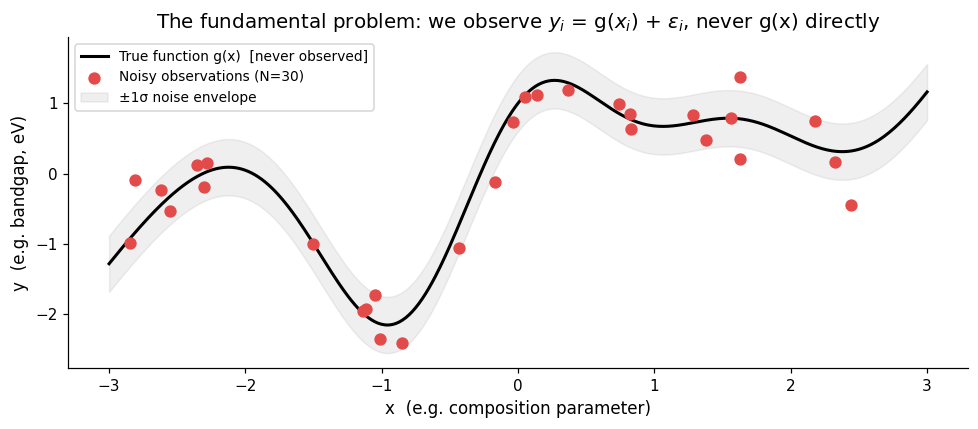

We have 30 noisy observations of a function we cannot see.
Noise level σ = 0.4. Our model must recover g(x), not memorise the noise.


In [ ]:
# ── Define the true function g(x) ────────────────────────────────────────────
# Imagine this is the true relationship between some physical property
# and a composition parameter — e.g. bandgap vs alloying fraction

def g_true(x):
    """True underlying function. In reality we never know this."""
    return np.sin(2 * x) + 0.5 * x + np.exp(-0.3 * x**2) * np.cos(3 * x)

# Generate the clean signal
x_plot = np.linspace(-3, 3, 500)
y_true = g_true(x_plot)

# Simulate noisy observations (what an experimentalist actually measures)
noise_level = 0.4
n_obs = 30
x_obs = np.random.uniform(-3, 3, n_obs)
y_obs = g_true(x_obs) + np.random.normal(0, noise_level, n_obs)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_plot, y_true, 'k-', lw=2, label='True function g(x)  [never observed]')
ax.scatter(x_obs, y_obs, c='#E24B4A', s=50, zorder=5, label=f'Noisy observations (N={n_obs})')
ax.fill_between(x_plot, y_true - noise_level, y_true + noise_level,
                alpha=0.12, color='gray', label='±1σ noise envelope')
ax.set_xlabel('x  (e.g. composition parameter)')
ax.set_ylabel('y  (e.g. bandgap, eV)')
ax.set_title('The fundamental problem: we observe $y_i$ = g($x_i$) + $ε_i$, never g(x) directly')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'We have {n_obs} noisy observations of a function we cannot see.')
print(f'Noise level σ = {noise_level}. Our model must recover g(x), not memorise the noise.')

---
## Part 2 — Comparing Function Families

Different ML algorithms differ mainly in **what functional forms they allow** for $f(x; \theta)$.

The parameters $\theta$ are then learned by minimising a loss function.

We compare three function families on the same data:

| Family | Form of f(x; θ) | Parameters θ |
|---|---|---|
| Linear | $f = \theta_0 + \theta_1 x$ | 2 |
| Polynomial (degree d) | $f = \sum_{k=0}^{d} \theta_k x^k$ | d+1 |
| Neural network | Composition of linear + nonlinear layers | Thousands |

**Key insight:**

The function family is the hypothesis space. A model can only find $g(x)$ if $g$ lives inside that space.

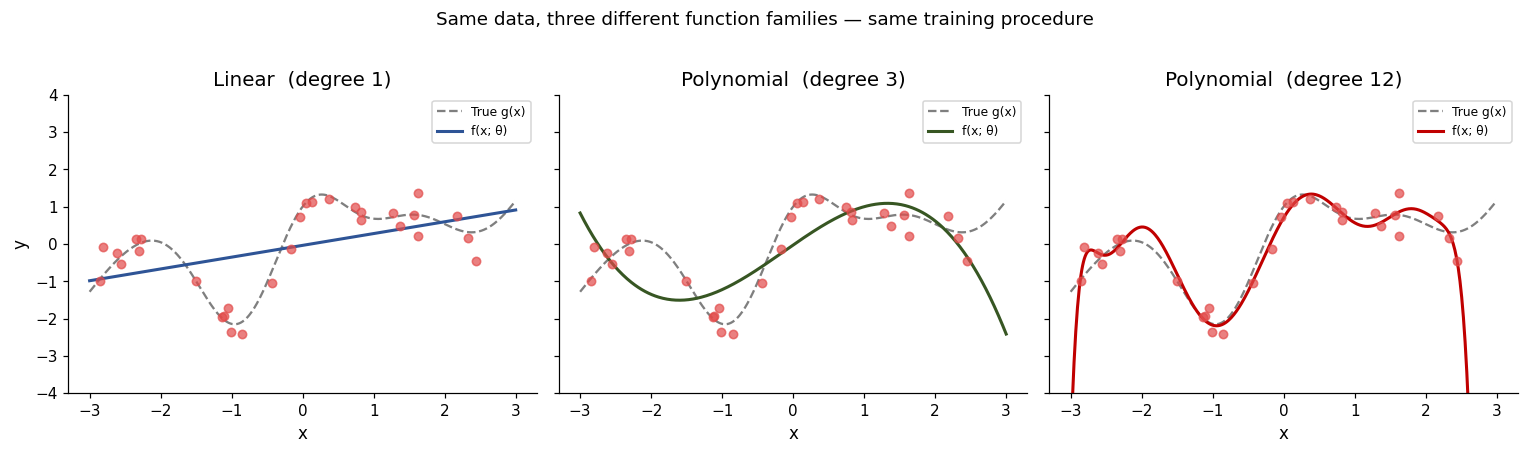

Linear      train MAE = 0.7969
Poly-3      train MAE = 0.5647
Poly-12     train MAE = 0.1856


In [ ]:
# ── Fit three function families to the same data ──────────────────────────────

X_obs = x_obs.reshape(-1, 1)
X_plot = x_plot.reshape(-1, 1)

# 1. Linear model
lin = LinearRegression().fit(X_obs, y_obs)
y_lin = lin.predict(X_plot)

# 2. Polynomial models (degree 3 and degree 12)
poly3  = make_pipeline(PolynomialFeatures(3),  LinearRegression()).fit(X_obs, y_obs)
poly12 = make_pipeline(PolynomialFeatures(12), LinearRegression()).fit(X_obs, y_obs)
y_poly3  = poly3.predict(X_plot)
y_poly12 = poly12.predict(X_plot)

# ── Plot all four ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
titles = ['Linear  (degree 1)', 'Polynomial  (degree 3)', 'Polynomial  (degree 12)']
preds  = [y_lin, y_poly3, y_poly12]
colors = ['#2E5496', '#375623', '#C00000']

for ax, title, pred, col in zip(axes, titles, preds, colors):
    ax.plot(x_plot, y_true, 'k--', lw=1.5, alpha=0.5, label='True g(x)')
    ax.scatter(x_obs, y_obs, c='#E24B4A', s=30, zorder=5, alpha=0.7)
    ax.plot(x_plot, pred, '-', color=col, lw=2, label=f'f(x; θ)')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylim(-4, 4)
    ax.legend(fontsize=8)

axes[0].set_ylabel('y')
plt.suptitle('Same data, three different function families — same training procedure', y=1.02)
plt.tight_layout()
plt.show()

# Print training errors
for name, model in [('Linear', lin), ('Poly-3', poly3), ('Poly-12', poly12)]:
    train_pred = model.predict(X_obs)
    print(f'{name:10s}  train MAE = {mean_absolute_error(y_obs, train_pred):.4f}')

### 🔍 Discussion

- **Linear**: low expressiveness — misses the curvature of g(x) entirely. High bias, low variance. This is **underfitting**.
- **Poly-3**: reasonable approximation in the data-rich region.
- **Poly-15**: fits every observation almost perfectly — but look at the edges. It oscillates wildly in regions with few data points. Low bias, high variance. This is **overfitting**.

> **The key question is never "does the model fit the training data well" — it is "does the model recover g(x)".**

---
## Part 3 — Overfitting and Regularization

Overfitting happens when the model is **expressive enough to memorize the noise** in the training set.

The fix is regularization — adding a penalty on model complexity to the loss:

$$L(\theta) = \underbrace{\frac{1}{N}\sum_i (f(x_i;\theta) - y_i)^2}_{\text{data fit}} + \underbrace{\lambda ||\theta||^2}_{\text{L2 regularisation}}$$

Large $\lambda$ forces $\theta$ to stay small → simpler, smoother model. Small $\lambda$ → model free to overfit.

**Physical analogy:** $\lambda$ is a Lagrange multiplier penalizing model complexity. Exactly as in constrained optimization in mechanics.

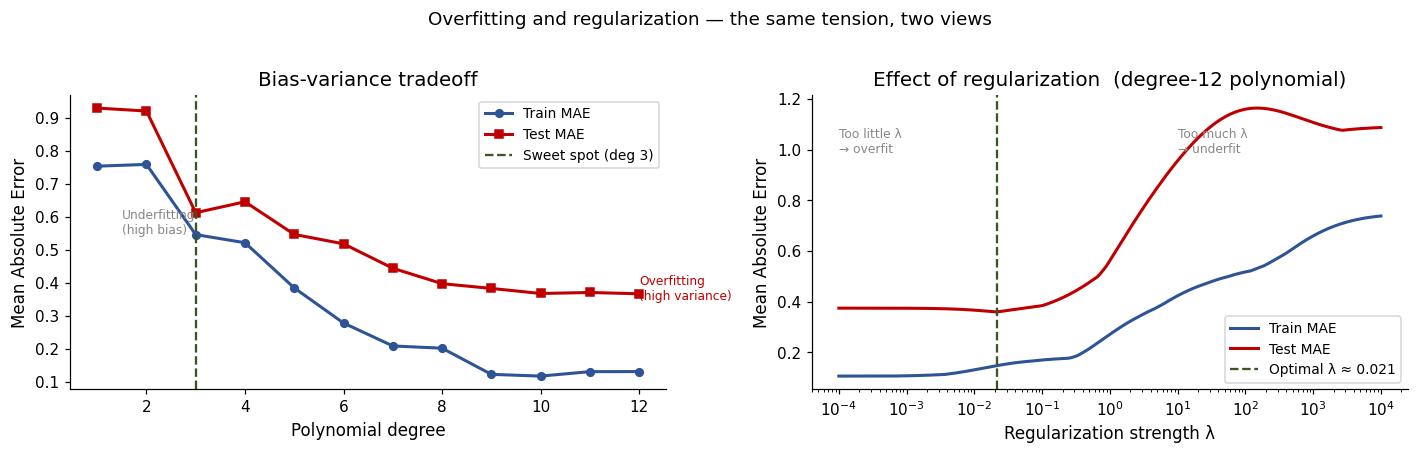

Best test MAE at degree 3:   0.6124
Best test MAE at degree 12:  0.3668
Optimal regularization λ:    0.0215


In [ ]:
# ── Bias-variance tradeoff across polynomial degrees ─────────────────────────
# Split data into train and test — the test set represents unseen data

x_train, x_test, y_train, y_test = train_test_split(
    x_obs, y_obs, test_size=0.3, random_state=7)

X_train = x_train.reshape(-1, 1)
X_test  = x_test.reshape(-1, 1)

degrees = range(1, 13)
train_errors, test_errors = [], []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), Ridge(alpha=1e-2))
    model.fit(X_train, y_train)
    train_errors.append(mean_absolute_error(y_train, model.predict(X_train)))
    test_errors.append(mean_absolute_error(y_test,  model.predict(X_test)))

# ── Regularization: same high-degree model, different λ ──────────────────────
lambdas = np.logspace(-4, 4, 200)
train_reg, test_reg = [], []

for lam in lambdas:
    model = make_pipeline(PolynomialFeatures(12), Ridge(alpha=lam))
    model.fit(X_train, y_train)
    train_reg.append(mean_absolute_error(y_train, model.predict(X_train)))
    test_reg.append(mean_absolute_error(y_test,  model.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: degree sweep
ax = axes[0]
ax.plot(degrees, train_errors, 'o-', color='#2E5496', lw=2, ms=5, label='Train MAE')
ax.plot(degrees, test_errors,  's-', color='#C00000', lw=2, ms=5, label='Test MAE')
ax.axvline(3, color='#375623', ls='--', lw=1.5, label='Sweet spot (deg 3)')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Bias-variance tradeoff')
ax.annotate('Underfitting\n(high bias)', xy=(1.5, 0.55), fontsize=8, color='#888')
ax.annotate('Overfitting\n(high variance)', xy=(12, 0.35), fontsize=8, color='#C00000')
ax.legend(fontsize=9)

# Right: regularization sweep
ax = axes[1]
ax.semilogx(lambdas, train_reg, '-', color='#2E5496', lw=2, label='Train MAE')
ax.semilogx(lambdas, test_reg,  '-', color='#C00000', lw=2, label='Test MAE')
best_lam = lambdas[np.argmin(test_reg)]
ax.axvline(best_lam, color='#375623', ls='--', lw=1.5, label=f'Optimal λ ≈ {best_lam:.3f}')
ax.set_xlabel('Regularization strength λ')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Effect of regularization  (degree-12 polynomial)')
ax.annotate('Too little λ\n→ overfit', xy=(1e-4, max(test_reg)*0.85), fontsize=8, color='#888')
ax.annotate('Too much λ\n→ underfit', xy=(10, max(test_reg)*0.85), fontsize=8, color='#888')
ax.legend(fontsize=9)

plt.suptitle('Overfitting and regularization — the same tension, two views', y=1.02)
plt.tight_layout()
plt.show()

print(f'Best test MAE at degree 3:   {test_errors[2]:.4f}')
print(f'Best test MAE at degree 12:  {test_errors[11]:.4f}')
print(f'Optimal regularization λ:    {best_lam:.4f}')

### 🔍 What to notice

- Train error always decreases as degree increases — more parameters = better training fit
- Test error has a minimum — after which more expressiveness hurts
- Regularization recovers a well-behaved model even from a degree-12 polynomial
- The optimal λ is a **hyperparameter** — set before training, not learned from data

> **In physical sciences, a lot of the times, datasets are small by construction. Overfitting is the default failure mode, not the exception.**

---
## Part 4 — Training a Neural Network From Scratch

We now build a minimal neural network using only numpy — no ML libraries. This makes the mathematics visible.

Architecture: input → hidden layer (tanh) → output

$$f(x; \theta) = W_2 \cdot \tanh(W_1 x + b_1) + b_2$$

Training: gradient descent on mean squared error loss

$$L(\theta) = \frac{1}{N}\sum_i (f(x_i; \theta) - y_i)^2$$

Gradients computed by backpropagation — the chain rule, implemented by hand.

In [ ]:
# ── Minimal neural network in pure numpy ─────────────────────────────────────

class TinyNet:
    """One hidden layer neural network. Input dim=1, output dim=1."""

    def __init__(self, n_hidden=20, lr=0.01, seed=0):
        rng = np.random.default_rng(seed)
        # Xavier initialization — prevents vanishing/exploding gradients
        self.W1 = rng.normal(0, np.sqrt(2/1),        (n_hidden, 1))   # (H, 1)
        self.b1 = np.zeros((n_hidden, 1))                              # (H, 1)
        self.W2 = rng.normal(0, np.sqrt(2/n_hidden), (1, n_hidden))    # (1, H)
        self.b2 = np.zeros((1, 1))                                     # (1, 1)
        self.lr = lr
        self.losses = []

    def forward(self, x):
        """Forward pass. x shape: (1, N)"""
        self.x   = x
        self.z1  = self.W1 @ x + self.b1    # pre-activation  (H, N)
        self.a1  = np.tanh(self.z1)          # activation      (H, N)
        self.out = self.W2 @ self.a1 + self.b2  # output       (1, N)
        return self.out

    def backward(self, y):
        """Backpropagation — chain rule applied to the computational graph."""
        N = y.shape[1]

        # Output layer gradients
        dL_dout = 2 * (self.out - y) / N         # dL/d(output)
        dL_dW2  = dL_dout @ self.a1.T            # dL/dW2
        dL_db2  = dL_dout.sum(axis=1, keepdims=True)

        # Hidden layer gradients — chain rule through tanh
        dL_da1  = self.W2.T @ dL_dout           # dL/d(a1)
        dL_dz1  = dL_da1 * (1 - self.a1**2)    # d(tanh)/dz = 1 - tanh²
        dL_dW1  = dL_dz1 @ self.x.T
        dL_db1  = dL_dz1.sum(axis=1, keepdims=True)

        # Gradient descent parameter update
        self.W2 -= self.lr * dL_dW2
        self.b2 -= self.lr * dL_db2
        self.W1 -= self.lr * dL_dW1
        self.b1 -= self.lr * dL_db1

    def train(self, x, y, epochs=5000):
        X = x.reshape(1, -1)
        Y = y.reshape(1, -1)
        for ep in range(epochs):
            pred = self.forward(X)
            loss = np.mean((pred - Y)**2)
            self.backward(Y)
            if ep % 500 == 0:
                self.losses.append((ep, loss))
        return self

    def predict(self, x):
        return self.forward(x.reshape(1, -1)).flatten()


# Train three networks of different sizes
configs = [(4, '4 neurons'), (20, '20 neurons'), (100, '100 neurons')]
nets = []
for n_h, label in configs:
    net = TinyNet(n_hidden=n_h, lr=0.005, seed=42)
    net.train(x_obs, y_obs, epochs=8000)
    nets.append((net, label))
    print(f'Trained {label:12s}  final loss = {net.losses[-1][1]:.6f}')

Trained 4 neurons     final loss = 0.129704
Trained 20 neurons    final loss = 0.130784
Trained 100 neurons   final loss = 0.130856


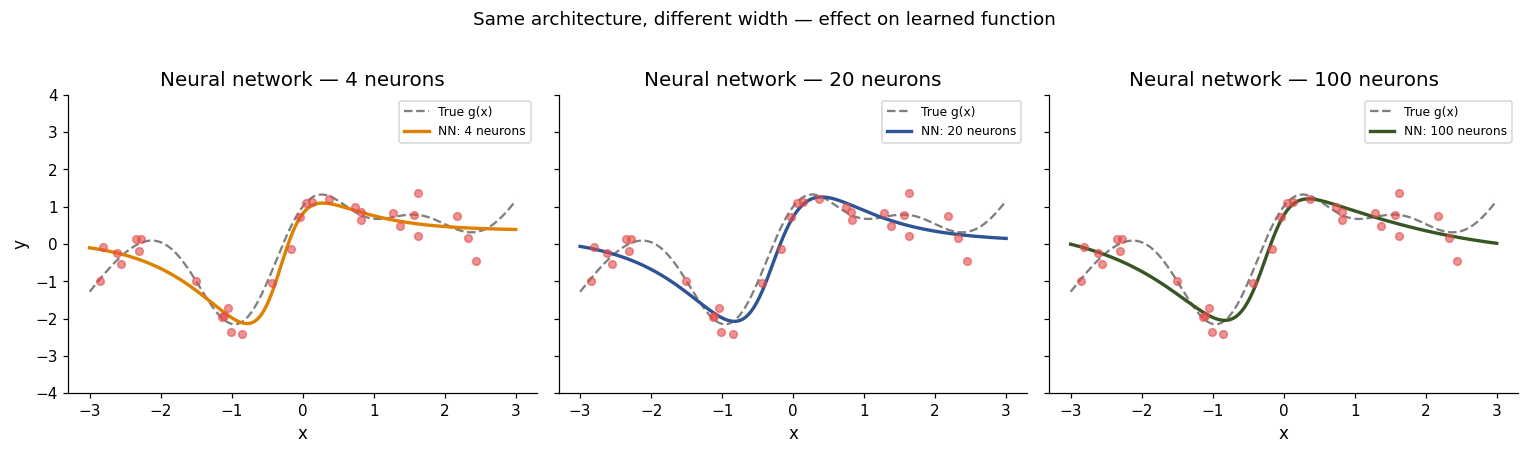

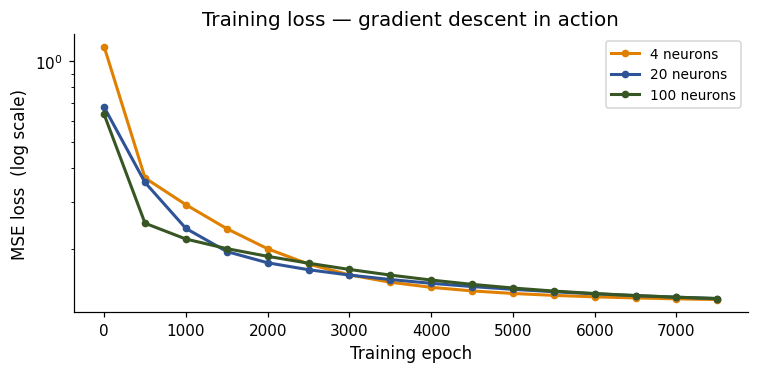

In [ ]:
# ── Plot: learned function vs true function ───────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ['#E08000', '#2E5496', '#375623']

for ax, (net, label), col in zip(axes, nets, colors):
    y_pred = net.predict(x_plot)
    ax.plot(x_plot, y_true,  'k--', lw=1.5, alpha=0.5, label='True g(x)')
    ax.scatter(x_obs, y_obs, c='#E24B4A', s=25, zorder=5, alpha=0.6)
    ax.plot(x_plot, y_pred,  '-', color=col, lw=2.2, label=f'NN: {label}')
    ax.set_title(f'Neural network — {label}')
    ax.set_xlabel('x')
    ax.set_ylim(-4, 4)
    ax.legend(fontsize=8)

axes[0].set_ylabel('y')
plt.suptitle('Same architecture, different width — effect on learned function', y=1.02)
plt.tight_layout()
plt.show()

# ── Plot: training loss curves ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
for (net, label), col in zip(nets, colors):
    epochs_logged, losses_logged = zip(*net.losses)
    ax.semilogy(epochs_logged, losses_logged, '-o', color=col,
                ms=4, lw=2, label=label)
ax.set_xlabel('Training epoch')
ax.set_ylabel('MSE loss  (log scale)')
ax.set_title('Training loss — gradient descent in action')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 🔍 What just happened

- The network updated ~8,000 times, each time computing the gradient via backpropagation and stepping downhill
- **4 neurons**: not expressive enough — underfits the complex shape
- **20 neurons**: good balance — recovers the main structure of g(x)
- **100 neurons**: risk of overfitting without regularization — check the behavior at the edges
- The loss curves show gradient descent working — exponential decay is typical for well-conditioned problems

> **This is exactly what CGCNN, MEGNet, and every other materials ML model does — gradient descent on a loss function, backpropagation through a computational graph. The graph is more complex; the principle is identical.**

---
## Part 5 — Universal Approximation: What a NN Can and Cannot Do

The **universal approximation theorem** says: a sufficiently wide single-hidden-layer network can approximate any continuous function on a compact domain.

But this has important caveats for physical sciences:

- ✅ Approximates well **within** the training domain (interpolation)
- ❌ No guarantee of correct behaviour **outside** the training domain (extrapolation)
- ❌ Does not discover **explicit physical laws** — it finds a numerical approximation
- ❌ Does not guarantee **interpretability** — the parameters θ have no physical meaning

We demonstrate this now with a sharp extrapolation test.

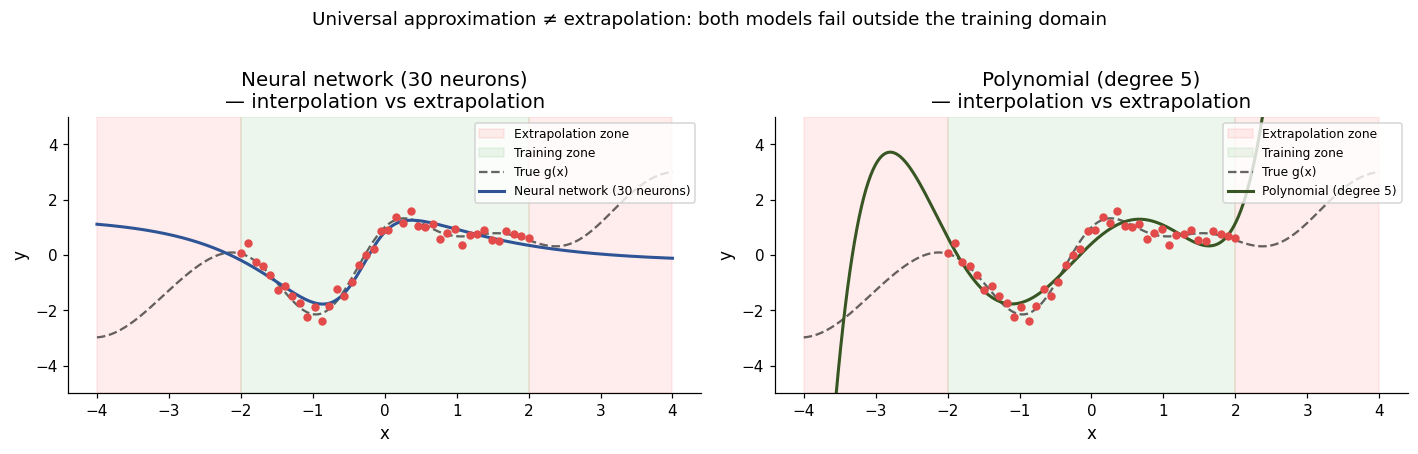

Neural net    interpolation MAE = 0.2010   extrapolation MAE = 1.6917   (ratio 8.4×)
Polynomial    interpolation MAE = 0.3046   extrapolation MAE = 22.1237   (ratio 72.6×)


In [ ]:
# ── Extrapolation failure demonstration ──────────────────────────────────────
# Train on x ∈ [-2, 2], then ask for predictions at x ∈ [-4, 4]

# Training region: only the middle part
x_train_extrap = np.linspace(-2, 2, 40)
y_train_extrap = g_true(x_train_extrap) + np.random.normal(0, 0.2, 40)

# Full domain for prediction
x_full = np.linspace(-4, 4, 500)
y_full_true = g_true(x_full)

# Train a neural network on the limited region
net_extrap = TinyNet(n_hidden=30, lr=0.003, seed=0)
net_extrap.train(x_train_extrap, y_train_extrap, epochs=10000)
y_full_pred = net_extrap.predict(x_full)

# Compare with a polynomial as well
poly_extrap = make_pipeline(PolynomialFeatures(5), LinearRegression())
poly_extrap.fit(x_train_extrap.reshape(-1,1), y_train_extrap)
y_poly_extrap = poly_extrap.predict(x_full.reshape(-1,1))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, label, y_pred, col in [
    (axes[0], 'Neural network (30 neurons)', y_full_pred, '#2E5496'),
    (axes[1], 'Polynomial (degree 5)',        y_poly_extrap, '#375623')
]:
    ax.axvspan(-4, -2, alpha=0.07, color='red', label='Extrapolation zone')
    ax.axvspan(2,   4, alpha=0.07, color='red')
    ax.axvspan(-2,  2, alpha=0.07, color='green', label='Training zone')
    ax.plot(x_full, y_full_true, 'k--', lw=1.5, alpha=0.6, label='True g(x)')
    ax.scatter(x_train_extrap, y_train_extrap, c='#E24B4A', s=20, zorder=5)
    ax.plot(x_full, y_pred, '-', color=col, lw=2, label=label)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{label}\n— interpolation vs extrapolation')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Universal approximation ≠ extrapolation: both models fail outside the training domain',
             y=1.02)
plt.tight_layout()
plt.show()

# Quantify the failure
mask_interp = (x_full >= -2) & (x_full <= 2)
mask_extrap = ~mask_interp
for label, y_pred in [('Neural net', y_full_pred), ('Polynomial', y_poly_extrap)]:
    mae_in  = mean_absolute_error(y_full_true[mask_interp], y_pred[mask_interp])
    mae_out = mean_absolute_error(y_full_true[mask_extrap], y_pred[mask_extrap])
    print(f'{label:12s}  interpolation MAE = {mae_in:.4f}   extrapolation MAE = {mae_out:.4f}   '
          f'(ratio {mae_out/mae_in:.1f}×)')